用多项式函数来拟合从余弦函数中采样出的带噪声数据

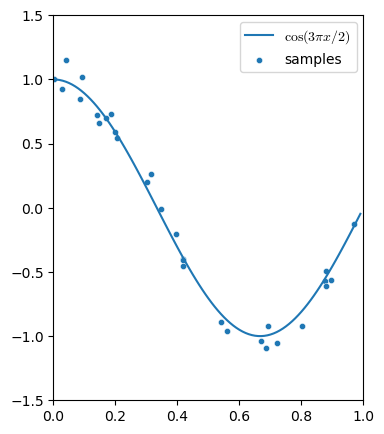

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


def true_fun(X):
    return np.cos(1.5 * np.pi * X)


plt.rcParams.update({
    "mathtext.fontset": 'cm',
    "axes.unicode_minus": True,
})

np.random.seed(1)

n_samples = 30
X = np.random.rand(n_samples)
y = true_fun(X) + np.random.randn(n_samples) * 0.1
X_test = np.arange(0, 1, 0.01)

fig, ax = plt.subplots(figsize=(4, 5))
sns.lineplot(x=X_test, y=true_fun(X_test), label=r"$\cos (3 \pi x  / 2)$", ax=ax)
sns.scatterplot(x=X, y=y, s=20, label="samples", ax=ax)
ax.set(xlim=(0, 1), ylim=(-1.5, 1.5))

plt.show()

In [2]:
from sklearn.preprocessing import PolynomialFeatures

poly4 = PolynomialFeatures(degree=4, include_bias=False) # x -> [x, x^2, x^3, x^4] 四阶多项式特征 不含常数项
X4 = poly4.fit_transform(X[:, np.newaxis])

X4 # 第i列是x的i次方, i = 1, 2, 3, 4

array([[4.17022005e-01, 1.73907352e-01, 7.25231927e-02, 3.02437672e-02],
       [7.20324493e-01, 5.18867376e-01, 3.73752880e-01, 2.69223354e-01],
       [1.14374817e-04, 1.30815988e-08, 1.49620548e-12, 1.71128228e-16],
       [3.02332573e-01, 9.14049845e-02, 2.76347041e-02, 8.35487119e-03],
       [1.46755891e-01, 2.15372915e-02, 3.16072440e-03, 4.63854925e-04],
       [9.23385948e-02, 8.52641608e-03, 7.87317280e-04, 7.26997712e-05],
       [1.86260211e-01, 3.46928663e-02, 6.46190062e-03, 1.20359498e-03],
       [3.45560727e-01, 1.19412216e-01, 4.12641722e-02, 1.42592773e-02],
       [3.96767474e-01, 1.57424429e-01, 6.24608929e-02, 2.47824507e-02],
       [5.38816734e-01, 2.90323473e-01, 1.56431145e-01, 8.42877189e-02],
       [4.19194514e-01, 1.75724041e-01, 7.36625540e-02, 3.08789386e-02],
       [6.85219500e-01, 4.69525764e-01, 3.21728209e-01, 2.20454443e-01],
       [2.04452250e-01, 4.18007224e-02, 8.54625174e-03, 1.74730039e-03],
       [8.78117436e-01, 7.71090232e-01, 6.77107778e

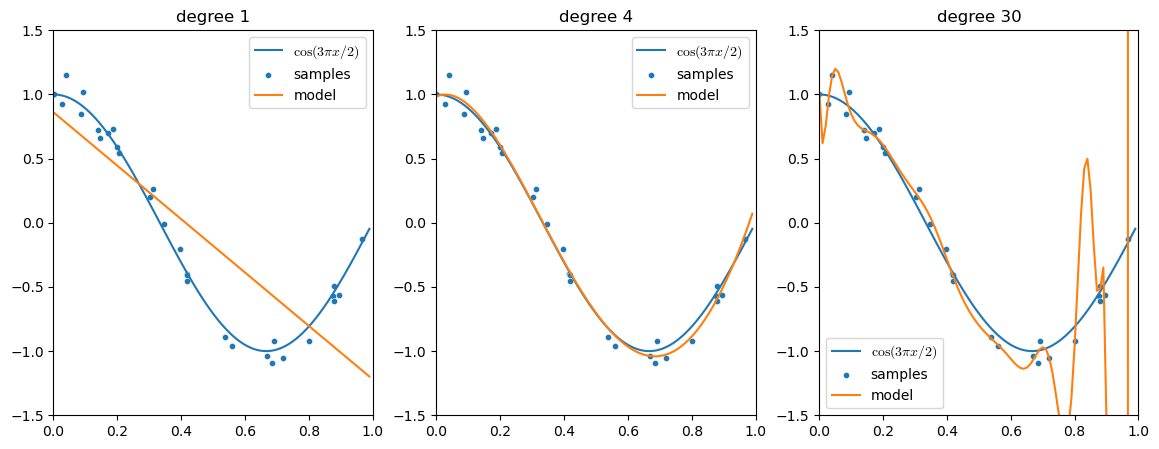

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

plt.rcParams.update({
    "mathtext.fontset": 'cm',
    "axes.unicode_minus": True,
})

fig, ax = plt.subplots(1, 3, figsize=(14, 5))
degrees = [1, 4, 30]
for i, degree in enumerate(degrees):

    polynomial_features = PolynomialFeatures(degree=degree, include_bias=True)
    linear_regression = LinearRegression()
    pipeline = Pipeline(
        [
            ("polynomial_features", polynomial_features),
            ("linear_regression", linear_regression),
        ]
    )
    pipeline.fit(X[:, np.newaxis], y)

    sns.lineplot(x=X_test, y=true_fun(X_test), label=r"$\cos (3 \pi x  / 2)$", ax=ax[i])
    sns.scatterplot(x=X, y=y, s=20, label="samples", ax=ax[i])
    sns.lineplot(x=X_test, y=pipeline.predict(X_test[:, np.newaxis]), label="model", ax=ax[i])

    ax[i].set(xlim=(0, 1), ylim=(-1.5, 1.5), title=f"degree {degree}")

plt.show()